In [ ]:

!pip install hdbscan
!pip install tqdm

In [2]:

import numpy as np
import pandas as pd
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:

print("Loading reduced embeddings...")
X_text_reduced = np.load('/content/drive/MyDrive/DATA/foi_embeddings_reduced.npy')
print("Reduced shape:", X_text_reduced.shape)


Loading reduced embeddings...
Reduced shape: (462682, 50)


In [4]:

print("Reducing dimensions further to 20D...")
pca_20 = PCA(n_components=20, random_state=42)
X_text_20D = pca_20.fit_transform(X_text_reduced)
print("Shape after 20D reduction:", X_text_20D.shape)

Reducing dimensions further to 20D...
Shape after 20D reduction: (462682, 20)


In [5]:

print("Standardizing embeddings...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_text_20D)


Standardizing embeddings...


In [6]:

print("Running HDBSCAN clustering...")

with tqdm(total=1, desc="HDBSCAN Clustering Progress") as pbar:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, prediction_data=True)
    cluster_labels = clusterer.fit_predict(X_scaled)
    pbar.update(1)

print("HDBSCAN clustering completed ✅")

Running HDBSCAN clustering...


HDBSCAN Clustering Progress:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
HDBSCAN Clustering Progress: 100%|██████████| 1/1 [1:03:12<00:00, 3792.33s/it]

HDBSCAN clustering completed ✅


In [7]:

print("Loading FOI text dataset...")
df = pd.read_csv('/content/drive/MyDrive/DATA/cleaned_embedding_data.csv')


Loading FOI text dataset...


In [8]:

df['hdbscan_cluster'] = cluster_labels


In [9]:

print("\nNumber of clusters found (excluding noise -1):", len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))
print("\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts())



Number of clusters found (excluding noise -1): 1638

Cluster distribution:
 75      179174
-1        27406
 18       22442
 692      16084
 1027     13511
          ...  
 433         15
 1000        15
 763         15
 623         15
 84          15
Name: count, Length: 1639, dtype: int64


In [10]:

df.to_csv('/content/drive/MyDrive/DATA/foi_with_hdbscan_clusters_20D.csv', index=False)
print("\nSaved final dataset with clusters ✅")


Saved final dataset with clusters ✅



Visualizing clusters...


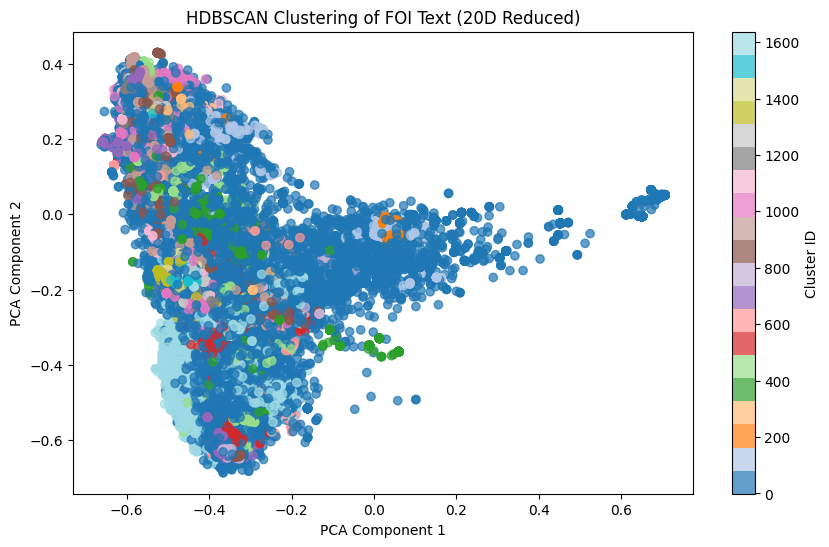

In [11]:

print("\nVisualizing clusters...")

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_text_20D)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['hdbscan_cluster'], cmap='tab20', alpha=0.7)
plt.title('HDBSCAN Clustering of FOI Text (20D Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()